## lab 02 :  Simple Linear Regression :

- Name : Muhammad Fasih
- Roll no : 24F-AI-016



Task 1: Simple Linear Regression:-
- Load dataset: Use the Diabetes dataset from sklearn.datasets. Select one feature (bmi) to predict
the target (disease progression).
- Perform Exploratory Data Analysis (EDA):
    - Plot scatter plot of BMI vs. Disease Progression.
    - Check correlation.
- Implement Simple Linear Regression using sklearn.linear_model.LinearRegression:
    - Split data into training and testing sets.
    - Fit the model and predict disease progression.
    - Plot the regression line on the scatter plot.
- Evaluate the model using:
    - Mean Squared Error (MSE)
    - R² score
Does BMI alone explain most of the variation in disease progression? How does R² help explain this?


        BMI  Disease_Progression
0  0.061696                151.0
1 -0.051474                 75.0
2  0.044451                141.0
3 -0.011595                206.0
4 -0.036385                135.0


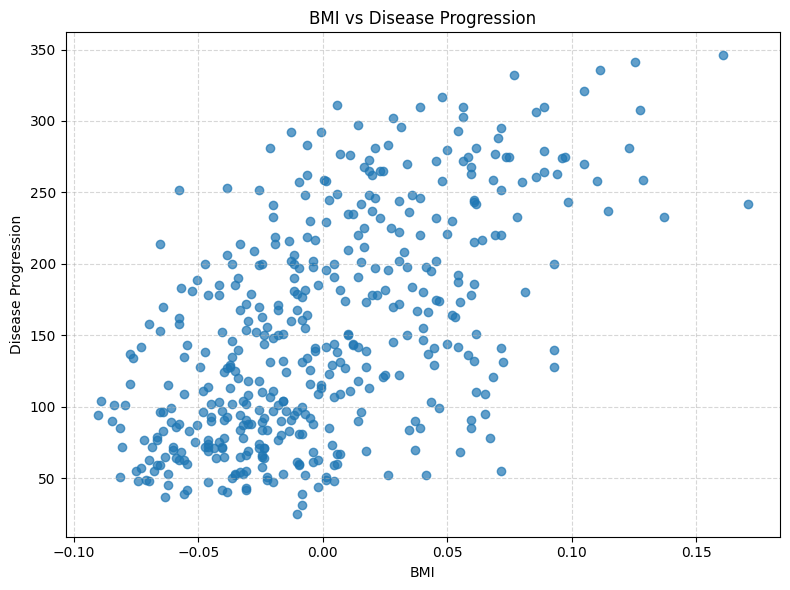

Correlation between BMI and Disease Progression: 0.5865
Mean Squared Error (MSE): 4061.8259
R^2 Score: 0.2334


c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


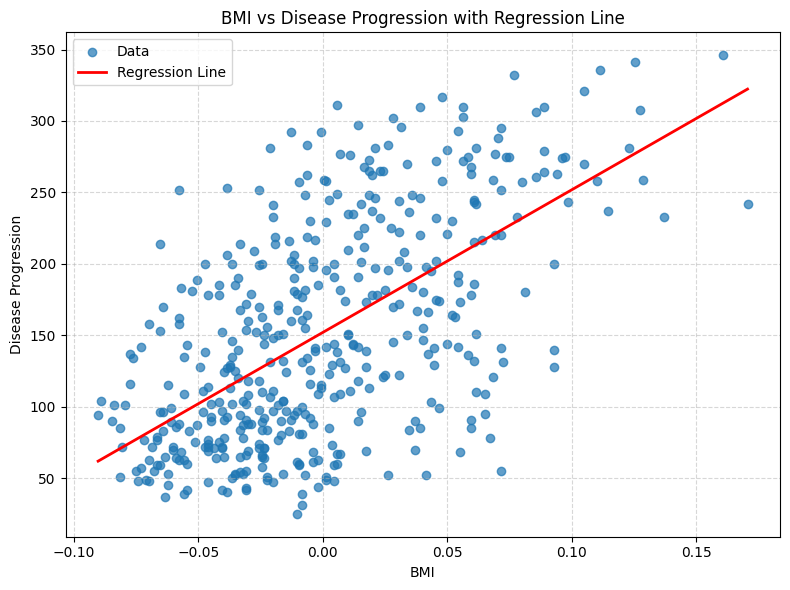

Interpretation:
R^2 tells us how much of the variation in disease progression is explained by BMI alone.
A higher R^2 means the model explains more of the variability in the target.
BMI alone may explain only a moderate amount of the variation in disease progression, depending on the R^2 value.


In [1]:
from sklearn.datasets import load_diabetes
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the diabetes dataset
import matplotlib.pyplot as plt

# Load dataset and select bmi as feature
diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
feature_names = diabetes.feature_names

bmi_idx = feature_names.index('bmi')
X_bmi = X[:, bmi_idx]

# Create DataFrame for EDA
df = pd.DataFrame({
    'BMI': X_bmi,
    'Disease_Progression': y
})

print(df.head())

# EDA: Scatter plot of BMI vs Disease Progression
plt.figure(figsize=(8, 6))
plt.scatter(df['BMI'], df['Disease_Progression'], alpha=0.7, color='tab:blue')
plt.title('BMI vs Disease Progression')
plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Check correlation
correlation = df['BMI'].corr(df['Disease_Progression'])
print(f"Correlation between BMI and Disease Progression: {correlation:.4f}")

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    df[['BMI']],
    df['Disease_Progression'],
    test_size=0.2,
    random_state=42
)

# Fit simple linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Predict on test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"R^2 Score: {r2:.4f}")

# Plot regression line on the scatter plot
x_line = np.linspace(df['BMI'].min(), df['BMI'].max(), 200)
y_line = model.predict(x_line.reshape(-1, 1))

plt.figure(figsize=(8, 6))
plt.scatter(df['BMI'], df['Disease_Progression'], alpha=0.7, color='tab:blue', label='Data')
plt.plot(x_line, y_line, color='red', linewidth=2, label='Regression Line')
plt.title('BMI vs Disease Progression with Regression Line')
plt.xlabel('BMI')
plt.ylabel('Disease Progression')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Interpretation
print("Interpretation:")
print("R^2 tells us how much of the variation in disease progression is explained by BMI alone.")
print("A higher R^2 means the model explains more of the variability in the target.")
print("BMI alone may explain only a moderate amount of the variation in disease progression, depending on the R^2 value.")

## Task 2: Multivariate Linear Regression: 
- Load dataset: Use the same Diabetes dataset, but include all 10 features to predict disease
progression.
- Perform EDA:
    - Generate a correlation heatmap between features and the target.
    - Create pair plots for selected features vs. target.
- Implement Multivariate Linear Regression:
    - Use all independent variables to predict the target
    - Fit and predict using the model.
- Compare actual vs. predicted values using:
    - Scatter plot (predicted vs. actual).
    -Residual plot.
- Evaluate model performance with:
    - MSE
    - RMSE
    - R² score
Which independent variable contributes the most to predicting disease progression?

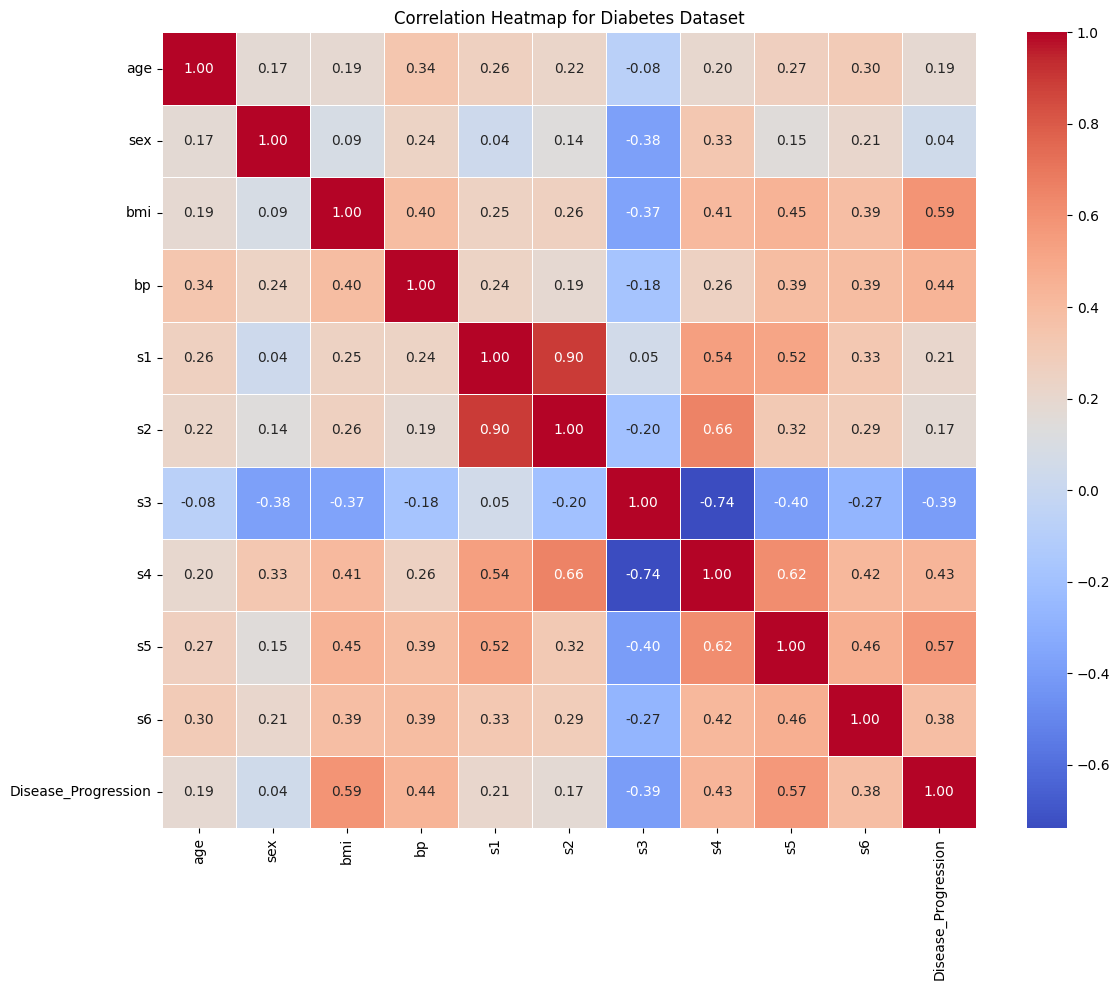

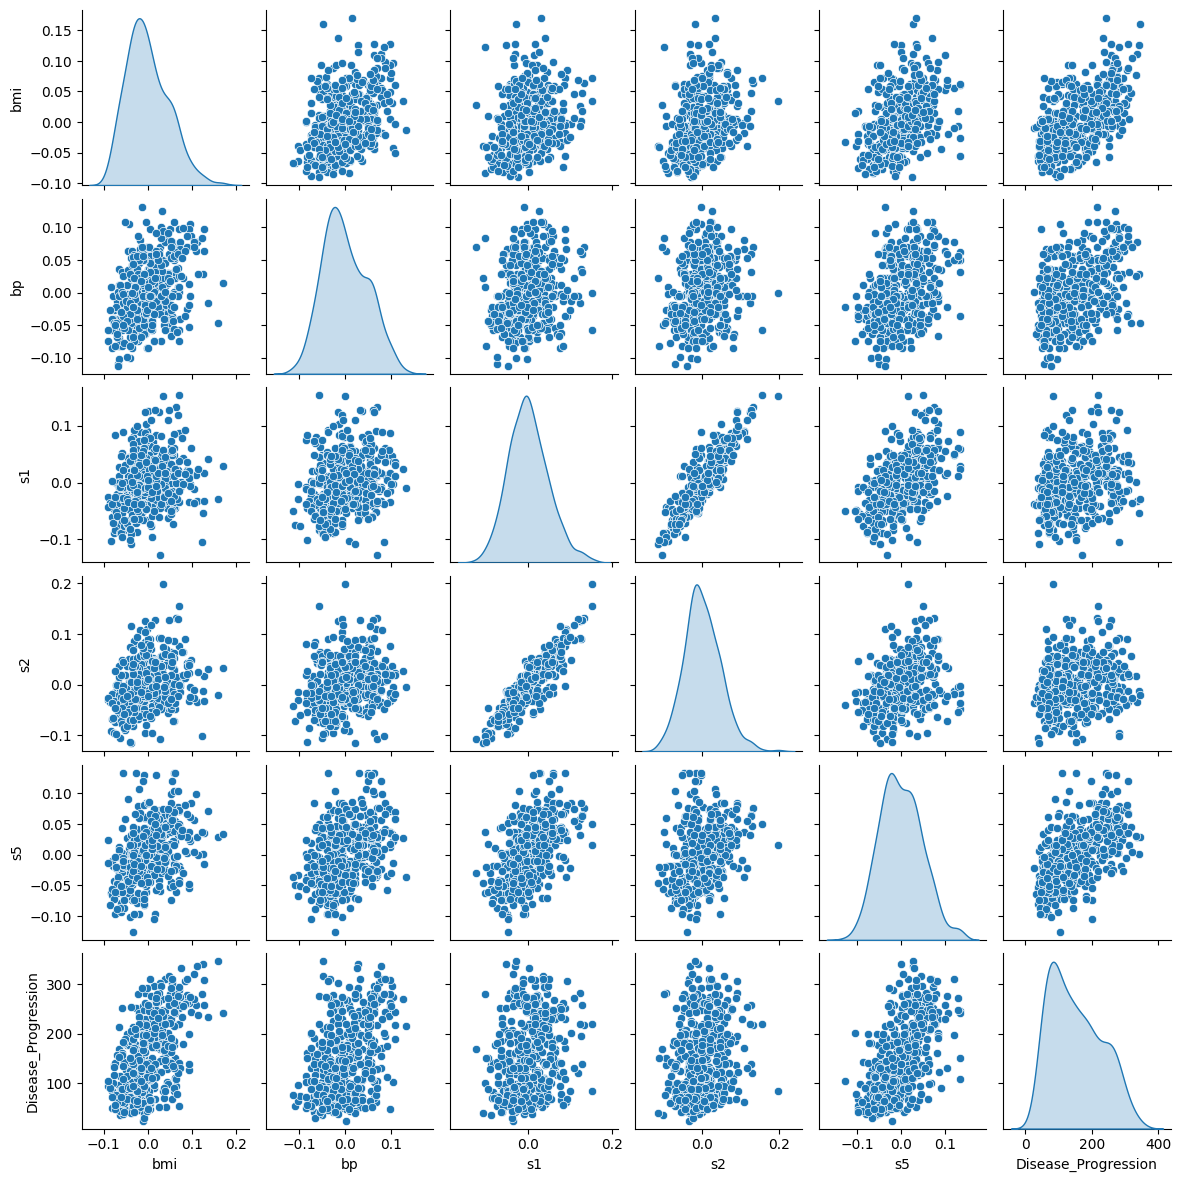

MSE: 2900.1936
RMSE: 53.8534
R^2 Score: 0.4526


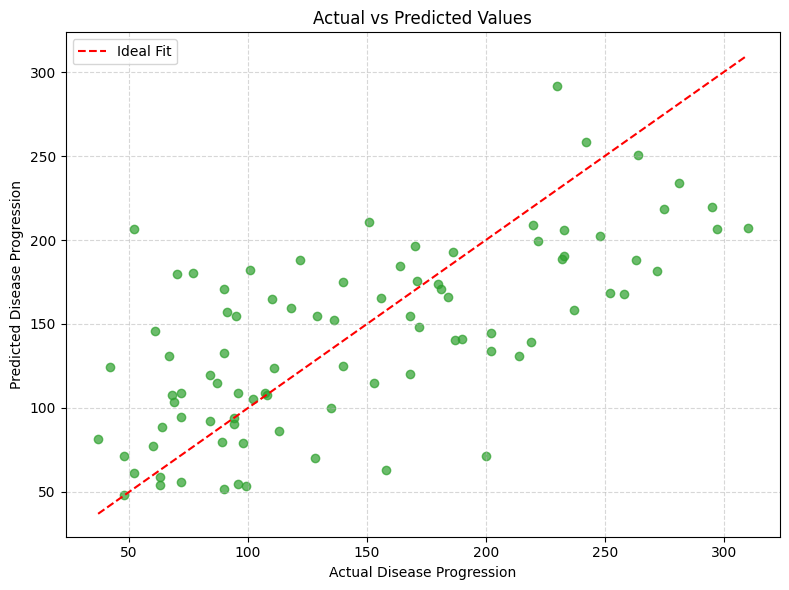

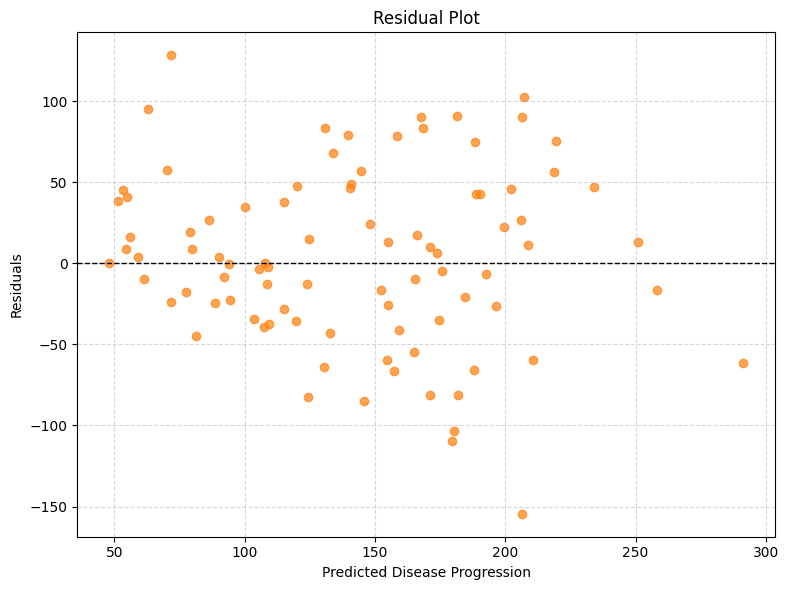


Feature Importance by Absolute Coefficient:
  Feature  Coefficient  Abs_Coefficient
4      s1  -931.488846       931.488846
8      s5   736.198859       736.198859
2     bmi   542.428759       542.428759
5      s2   518.062277       518.062277
3      bp   347.703844       347.703844
7      s4   275.317902       275.317902
1     sex  -241.964362       241.964362
6      s3   163.419983       163.419983
9      s6    48.670657        48.670657
0     age    37.904021        37.904021

The independent variable that contributes the most is 's1' with a coefficient of -931.4888.


In [3]:
import seaborn as sns

# Build a DataFrame with all 10 features and the target
X_df = pd.DataFrame(X, columns=feature_names)
y_series = pd.Series(y, name='Disease_Progression')
df_multivariate = pd.concat([X_df, y_series], axis=1)

# EDA: Correlation heatmap between features and target
plt.figure(figsize=(12, 10))
corr = df_multivariate.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap for Diabetes Dataset')
plt.tight_layout()
plt.show()

# EDA: Pair plot for selected features vs. target
selected_features = ['bmi', 'bp', 's1', 's2', 's5', 'Disease_Progression']
sns.pairplot(df_multivariate[selected_features], diag_kind='kde', height=2.0)
plt.show()

# Split the data into training and testing sets
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_df,
    y_series,
    test_size=0.2,
    random_state=42
)

# Fit multivariate linear regression model
multivariate_model = LinearRegression()
multivariate_model.fit(X_train_m, y_train_m)

# Predict on the test set
y_pred_m = multivariate_model.predict(X_test_m)

# Evaluate the model
mse_m = mean_squared_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mse_m)
r2_m = r2_score(y_test_m, y_pred_m)

print(f'MSE: {mse_m:.4f}')
print(f'RMSE: {rmse_m:.4f}')
print(f'R^2 Score: {r2_m:.4f}')

# Scatter plot: actual vs predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test_m, y_pred_m, alpha=0.7, color='tab:green')
plt.plot([y_test_m.min(), y_test_m.max()], [y_test_m.min(), y_test_m.max()], color='red', linestyle='--', label='Ideal Fit')
plt.xlabel('Actual Disease Progression')
plt.ylabel('Predicted Disease Progression')
plt.title('Actual vs Predicted Values')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()

# Residual plot
residuals = y_test_m - y_pred_m
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_m, residuals, alpha=0.7, color='tab:orange')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.xlabel('Predicted Disease Progression')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Determine which feature contributes the most
coef_df = pd.DataFrame({
    'Feature': X_df.columns,
    'Coefficient': multivariate_model.coef_
})

coef_df['Abs_Coefficient'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coefficient', ascending=False)

print('\nFeature Importance by Absolute Coefficient:')
print(coef_df[['Feature', 'Coefficient', 'Abs_Coefficient']])

most_influential = coef_df.iloc[0]
print(f"\nThe independent variable that contributes the most is '{most_influential['Feature']}' with a coefficient of {most_influential['Coefficient']:.4f}.")

## Task 3: Experimentation:
- Compare performance of simple vs. multivariate regression in terms of evaluation metrics.


Model Comparison:
                                    Model          MSE       RMSE       R^2
0            Simple Regression (BMI only)  4061.825928  63.732456  0.233350
1  Multivariate Regression (All Features)  2900.193628  53.853446  0.452603


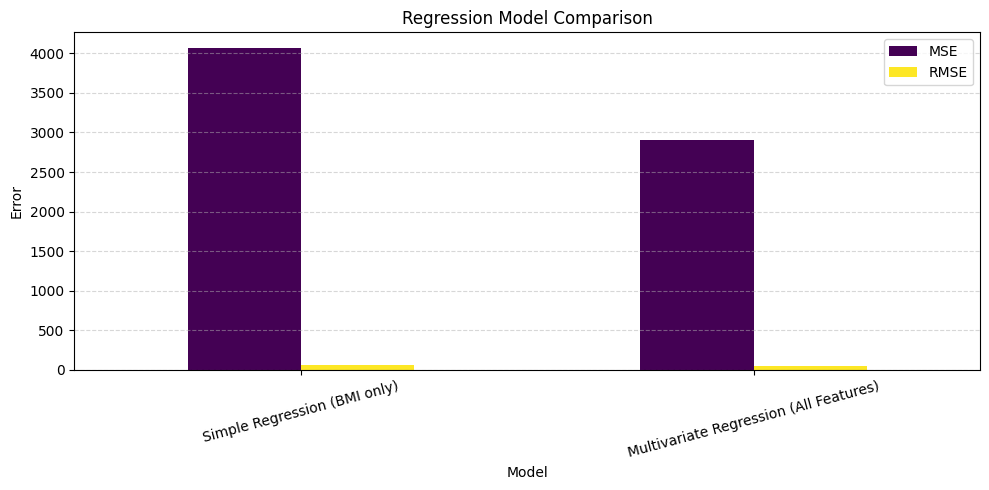


The multivariate model performs better because it has a higher R^2 and lower error values.


In [2]:
# Compare simple vs. multivariate regression performance

# Use the existing BMI-only dataset from the earlier notebook cell
if 'X_df' not in globals():
    X_df = pd.DataFrame(X, columns=feature_names)
if 'y_series' not in globals():
    y_series = pd.Series(y, name='Disease_Progression')

# Simple regression (BMI only)
simple_X_train, simple_X_test, simple_y_train, simple_y_test = train_test_split(
    df[['BMI']],
    df['Disease_Progression'],
    test_size=0.2,
    random_state=42
)

simple_model = LinearRegression()
simple_model.fit(simple_X_train, simple_y_train)
simple_y_pred = simple_model.predict(simple_X_test)

simple_mse = mean_squared_error(simple_y_test, simple_y_pred)
simple_rmse = np.sqrt(simple_mse)
simple_r2 = r2_score(simple_y_test, simple_y_pred)

# Multivariate regression (all features)
X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(
    X_df,
    y_series,
    test_size=0.2,
    random_state=42
)

multivariate_model = LinearRegression()
multivariate_model.fit(X_train_m, y_train_m)
y_pred_m = multivariate_model.predict(X_test_m)

mse_m = mean_squared_error(y_test_m, y_pred_m)
rmse_m = np.sqrt(mse_m)
r2_m = r2_score(y_test_m, y_pred_m)

# Summary table
comparison = pd.DataFrame({
    'Model': ['Simple Regression (BMI only)', 'Multivariate Regression (All Features)'],
    'MSE': [simple_mse, mse_m],
    'RMSE': [simple_rmse, rmse_m],
    'R^2': [simple_r2, r2_m]
})

print("Model Comparison:")
print(comparison)

# Optional visualization
comparison_plot = comparison.set_index('Model')[['MSE', 'RMSE']]
comparison_plot.plot(kind='bar', figsize=(10, 5), colormap='viridis')
plt.title('Regression Model Comparison')
plt.ylabel('Error')
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Interpretation
if r2_m > simple_r2:
    print("\nThe multivariate model performs better because it has a higher R^2 and lower error values.")
else:
    print("\nThe simple model performs similarly or better in this split. Compare the results carefully.")